# Transforming Distributions with SDEs
In the previous section, we observed how individual *points* are transformed by an SDE. Ultimately, we are interested in understanding how *distributions* are transformed by an SDE (or an ODE...). After all, our goal is to design ODEs and SDEs which transform a noisy distribution (such as the Gaussian $N(0, I_d)$), to the data distribution $p_{\text{data}}$ of interest. In this section, we will visualize how distributions are transformed by a very particular family of SDEs: *Langevin dynamics*.

First, let's define some distributions to play around with. In practice, there are two qualities one might hope a distribution to have:
1. The first quality is that one can measure the *density* of a distribution $p(x)$. This ensures that we can compute the gradient $\nabla \log p(x)$ of the log density. This quantity is known as the *score* of $p$, and paints a picture of the local geometry of the distribution. Using the score, we will construct and simulate the *Langevin dynamics*, a family of SDEs which "drive" samples toward the distribution $\pi$. In particular, the Langevin dynamics *preserve* the distribution $p(x)$. In Lecture 2, we will make this notion of driving more precise.
2. The second quality is that we can draw samples from the distribution $p(x)$.
For simple, toy distributions, such as Gaussians and simple mixture models, it is often true that both qualities are satisfied. For more complex choices of $p$, such as distributions over images, we can sample but cannot measure the density.

---
---
# 1. Define Gaussian Distribution with Log Density and Sample

In [1]:
import torch
import torch.nn as nn
import torch.distributions as D
import numpy as np

In [2]:
from fmtorch.distribution import Density
from fmtorch.sampler import Sampler

class GaussianSampler(nn.Module, Density, Sampler):
    """
    Two-dimensional Gaussian. Is a Density and a Sampleable. Wrapper around torch.distributions.MultivariateNormal
    """
    def __init__(self, mean, cov):
        """
        mean: shape (dim,)
        cov: shape (dim,dim)
        """
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("cov", cov)

    # @property 是 Python 的一个装饰器，它将一个 方法 变成一个 属性，
    # 这样我们可以像访问变量一样调用它，而不需要加 ()。
    @property
    def dim(self) -> int:
        return self.mean.shape[0]
    
    @property
    def distribution(self):
        return D.MultivariateNormal(self.mean, self.cov, validate_args=False)

    def sample(self, num_samples) -> torch.Tensor:
        return self.distribution.sample((num_samples,))

    def log_density(self, x: torch.Tensor):
        return self.distribution.log_prob(x).view(-1, 1)
    
    @classmethod
    def isotropic(cls, dim: int, std: float) -> "GaussianSampler":
        mean = torch.zeros(dim)
        cov = torch.eye(dim) * std ** 2
        return cls(mean, cov)


In [3]:
class GaussianMixtureSampler(nn.Module, Density, Sampler):
    """
    Two-dimensional Gaussian mixture model, and is a Density and a Sampleable. Wrapper around torch.distributions.MixtureSameFamily.
    """
    def __init__(
        self,
        means: torch.Tensor,  # nmodes x data_dim
        covs: torch.Tensor,  # nmodes x data_dim x data_dim
        weights: torch.Tensor,  # nmodes
    ):
        """
        means: shape (nmodes, 2)
        covs: shape (nmodes, 2, 2)
        weights: shape (nmodes, 1)
        """
        super().__init__()
        self.nmodes = means.shape[0]
        self.register_buffer("means", means)
        self.register_buffer("covs", covs)
        self.register_buffer("weights", weights)

    @property
    def dim(self) -> int:
        return self.means.shape[1]

    @property
    def distribution(self):
        return D.MixtureSameFamily(
                mixture_distribution=D.Categorical(probs=self.weights, validate_args=False),
                component_distribution=D.MultivariateNormal(
                    loc=self.means,
                    covariance_matrix=self.covs,
                    validate_args=False,
                ),
                validate_args=False,
            )

    def log_density(self, x: torch.Tensor) -> torch.Tensor:
        return self.distribution.log_prob(x).view(-1, 1)

    def sample(self, num_samples: int) -> torch.Tensor:
        return self.distribution.sample(torch.Size((num_samples,)))

    @classmethod
    def random_2D(
        cls, nmodes: int, scale_mean: float, std: float, seed = 0.0
    ) -> "GaussianMixtureSampler":
        torch.manual_seed(seed)
        # means 的每个分量都是 均匀分布在 [-scale/2, scale/2] 上，不会偏向某个方向。
        means = (torch.rand(nmodes, 2) - 0.5) * scale_mean
        covs = torch.diag_embed(torch.ones(nmodes, 2)) * std ** 2
        weights = torch.ones(nmodes)
        return cls(means, covs, weights)

    @classmethod
    def symmetric_2D(
        cls, nmodes: int, scale_mean: float, std: float, 
    ) -> "GaussianMixtureSampler":
        angles = torch.linspace(0, 2 * np.pi, nmodes + 1)[:nmodes]
        means = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1) * scale_mean
        covs = torch.diag_embed(torch.ones(nmodes, 2) * std ** 2)
        weights = torch.ones(nmodes) / nmodes
        return cls(means, covs, weights)

---
---
# 2. Visulate Density Distribution

In [4]:
from typing import Optional
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import seaborn as sns
import numpy as np

from fmtorch.solver import Solver

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
# Display data as an image, i.e., on a 2D regular raster.
def imshow_density(density: Density, bins: int, scale: float, ax: Optional[Axes] = None, **kwargs):
    # If no axis is provided, get the current axis
    if ax is None:
        ax = plt.gca()
    
    # Create a grid of points
    x = torch.linspace(-scale, scale, bins).to(device)
    y = torch.linspace(-scale, scale, bins).to(device)
    X, Y = torch.meshgrid(x, y)
    # bins x bins 网格，每个点是一个二维坐标
    xy = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)
    
    # Compute the log density at each point in the grid
    density = density.log_density(xy).reshape(bins, bins).T
    
    # Display the density as an image
    im = ax.imshow(density.cpu(), extent=[-scale, scale, -scale, scale], origin='lower', **kwargs)

# contour and contourf draw contour lines and filled contours, respectively. Except as noted, function signatures and return values are the same for both versions.
def contour_density(density: Density, bins: int, scale: float, ax: Optional[Axes] = None, **kwargs):
    # If no axis is provided, get the current axis
    if ax is None:
        ax = plt.gca()
    
    # Create a grid of points
    x = torch.linspace(-scale, scale, bins).to(device)
    y = torch.linspace(-scale, scale, bins).to(device)
    X, Y = torch.meshgrid(x, y)
    xy = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)
    
    # Compute the log density at each point in the grid
    density = density.log_density(xy).reshape(bins, bins).T
    
    # Display the density as a contour plot
    im = ax.contour(density.cpu(), extent=[-scale, scale, -scale, scale], origin='lower', **kwargs)


---
## 2.1 Visualize Gaussian density 

/Users/zewen/Documents/alwinyang/fmtorch/.venv/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


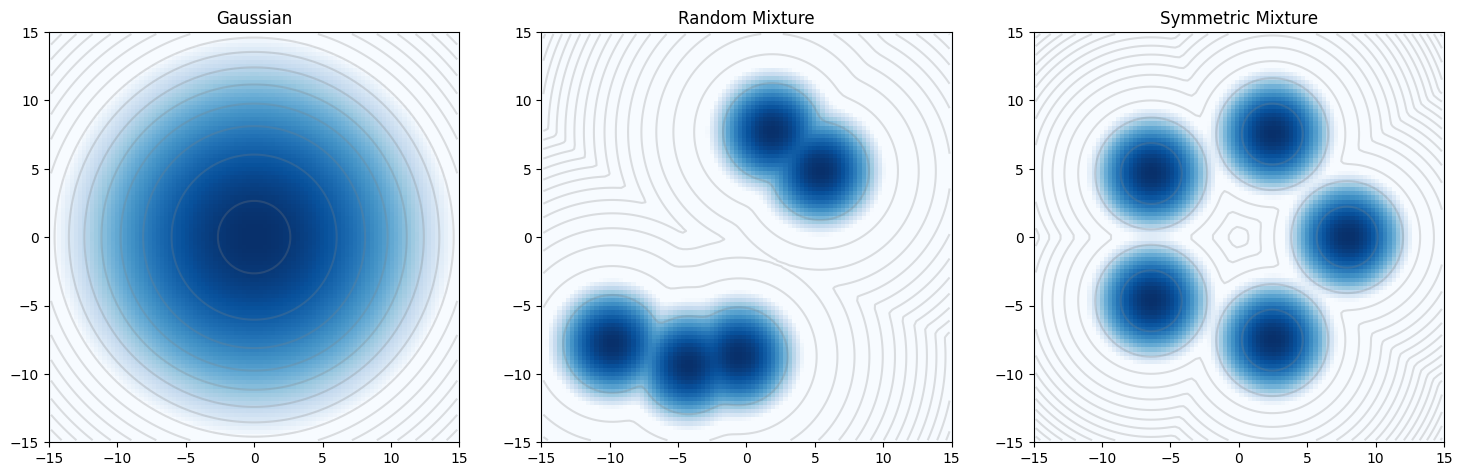

In [6]:
from fmtorch.sampler import GaussianSampler, GaussianMixtureSampler

# Visualize densities
densities = {
    "Gaussian": GaussianSampler(mean=torch.zeros(2), cov=10 * torch.eye(2)).to(device),
    "Random Mixture": GaussianMixtureSampler.random_2D(nmodes=5, scale_mean=20.0, std=1.0, seed=3.0).to(device),
    "Symmetric Mixture": GaussianMixtureSampler.symmetric_2D(nmodes=5, scale_mean=8.0, std=1.0).to(device),
}

fig, axes = plt.subplots(1,3, figsize=(18, 6))
bins = 100
scale = 15
for idx, (name, density) in enumerate(densities.items()):
    ax = axes[idx]
    ax.set_title(name)
    imshow_density(density, bins, scale, ax, vmin=-15, cmap=plt.get_cmap('Blues'))
    contour_density(density, bins, scale, ax, colors='grey', linestyles='solid', alpha=0.25, levels=20)
plt.show()

---
---
# 3. Simulate Density Langevin Dynamics

Simulate the (overdamped) Langevin dynamics $$dX_t = \frac{1}{2} \sigma^2\nabla \log p(X_t) dt + \sigma dW_t.$$


---
## 3.1 Define Langevin SDE

In [7]:
from fmtorch.diff_eq import SDE
from fmtorch.distribution import Density

In [8]:
class LangevinSDE(SDE):
    def __init__(self, sigma: float, density: Density):
        self.sigma = sigma
        self.density = density
        
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (batch_size, dim)
            - t: time, shape ()
        Returns:
            - drift: shape (batch_size, dim)
        """
        return 0.5 * self.sigma ** 2 * self.density.score(xt)
        
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Returns the diffusion coefficient of the ODE.
        Args:
            - xt: state at time t, shape (batch_size, dim)
            - t: time, shape ()
        Returns:
            - diffusion: shape (batch_size, dim)
        """
        return self.sigma * torch.ones_like(xt)


---
## 3.2 Visualize Distribution Changes

In [9]:
# First, let's define two utility functions...
def record_every_nth_index(num_timesteps: int, record_every_numberstep: int) -> torch.Tensor:
    """
    Compute the indices to record in the trajectory
    """
    if record_every_numberstep == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps - 1, record_every_numberstep),
            torch.tensor([num_timesteps - 1]),
        ]
    )

def graph_dynamics(
    num_samples: int, source_distribution_samples: Sampler, traget_density: Density, 
    simulator: Solver, timesteps: torch.Tensor, 
    record_every_numberstep: int, bins: int, scale: float
):
    """
    Plot the evolution of samples from source under the simulation scheme given by simulator (itself a discretization of an ODE or SDE).
    Args:
        - num_samples: the number of samples to simulate
        - source_distribution_samples: distribution from which we draw initial samples at t=0
        - simulator: the discertized simulation scheme used to simulate the dynamics
        - density: the target density
        - timesteps: the timesteps used by the simulator
        - plot_every_numStep: number of timesteps between consecutive plots
        - bins: number of bins for imshow
        - scale: scale for imshow
    """
    # Simulate
    x0 = source_distribution_samples.sample(num_samples)
    xts = simulator.simulate_with_trajectory(x0, timesteps)
    indices_to_plot = record_every_nth_index(len(timesteps), record_every_numberstep)
    plot_timesteps = timesteps[indices_to_plot]

    # Graph
    fig, axes = plt.subplots(2, len(plot_timesteps), figsize=(8*len(plot_timesteps), 16))
    axes = axes.reshape((2,len(plot_timesteps)))
    for t_idx in range(len(plot_timesteps)):
        t = plot_timesteps[t_idx].item()
        xt = xts[:,t_idx]

        # Scatter axes
        scatter_ax = axes[0, t_idx]
        imshow_density(traget_density, bins, scale, scatter_ax, vmin=-15, alpha=0.25, cmap=plt.get_cmap('Blues'))
        scatter_ax.scatter(xt[:,0].cpu(), xt[:,1].cpu(), marker='x', color='black', alpha=0.75, s=15)
        scatter_ax.set_title(f'Samples at t={t:.1f}', fontsize=15)
        scatter_ax.set_xticks([])
        scatter_ax.set_yticks([])

        # Kdeplot axes
        kdeplot_ax = axes[1, t_idx]
        imshow_density(traget_density, bins, scale, kdeplot_ax, vmin=-15, alpha=0.5, cmap=plt.get_cmap('Blues'))
        sns.kdeplot(x=xt[:,0].cpu(), y=xt[:,1].cpu(), alpha=0.5, ax=kdeplot_ax,color='grey')
        kdeplot_ax.set_title(f'Density of Samples at t={t:.1f}', fontsize=15)
        kdeplot_ax.set_xticks([])
        kdeplot_ax.set_yticks([])
        kdeplot_ax.set_xlabel("")
        kdeplot_ax.set_ylabel("")

    plt.show()

100%|██████████| 999/999 [00:01<00:00, 514.11it/s]


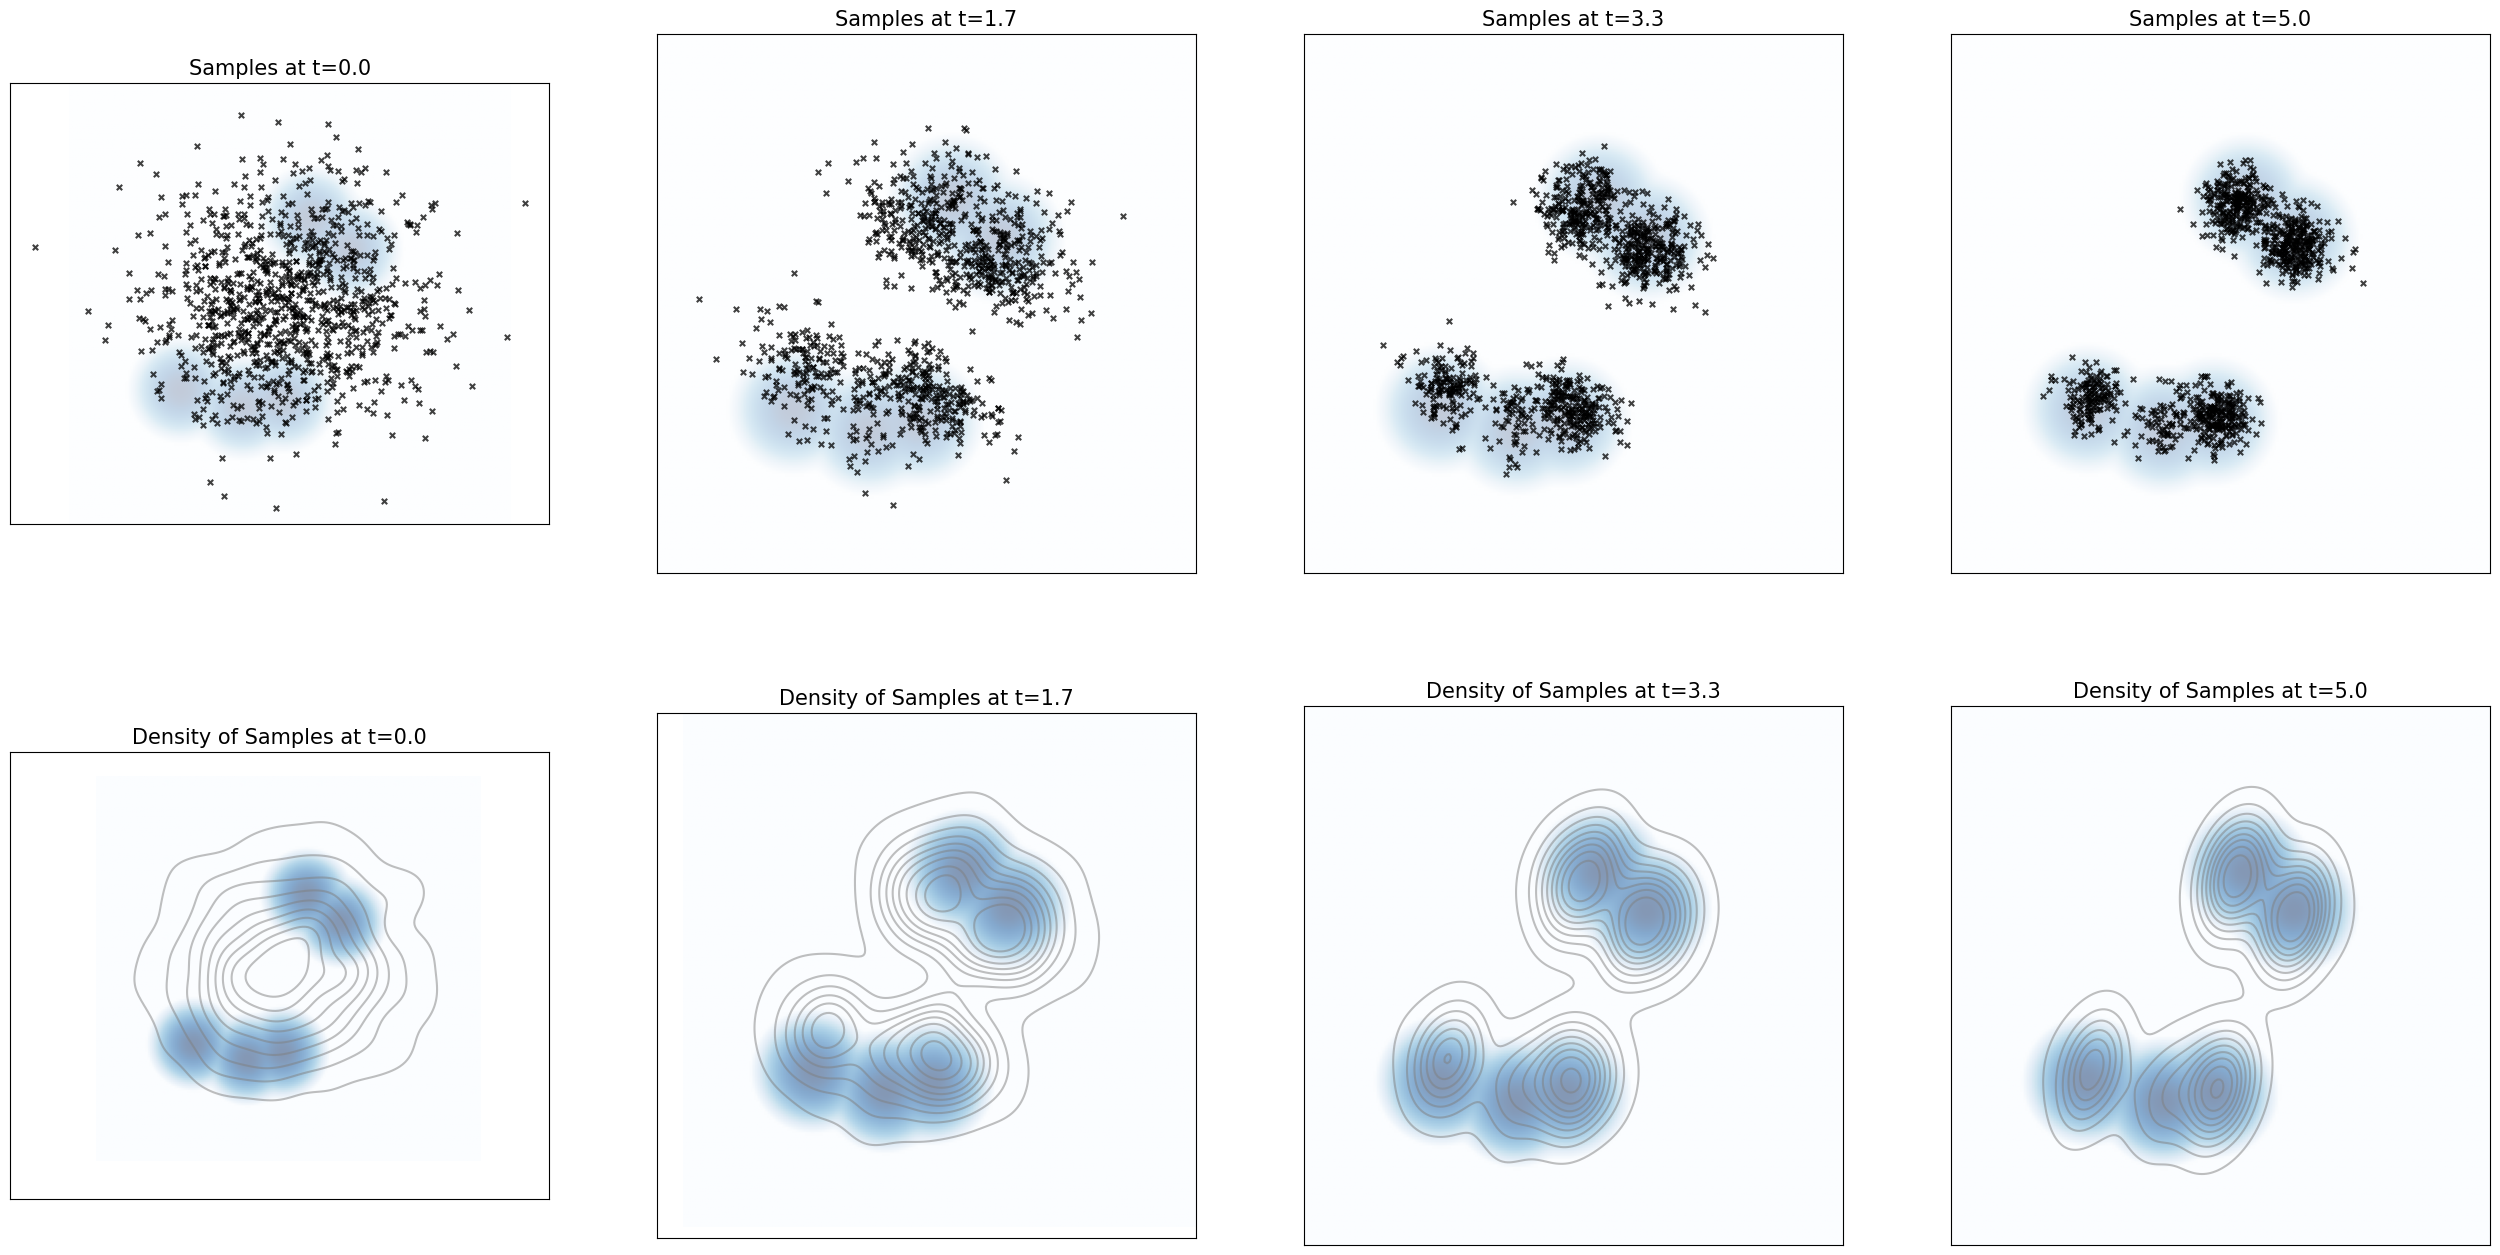

In [10]:
from fmtorch.solver import EulerMaruyamaSolver
from fmtorch.sampler import GaussianSampler, GaussianMixtureSampler

# Construct the simulator
target = GaussianMixtureSampler.random_2D(nmodes=5, scale_mean=15.0, std=0.75, seed=3.0).to(device)
sde = LangevinSDE(sigma = 10.0, density = target)
simulator = EulerMaruyamaSolver(sde)

# Graph the results!
graph_dynamics(
    num_samples = 1000,
    source_distribution_samples = GaussianSampler(mean=torch.zeros(2), cov=20 * torch.eye(2)).to(device),
    traget_density=target,
    simulator=simulator,
    timesteps=torch.linspace(0,5.0,1000).to(device),
    record_every_numberstep=334,
    bins=200,
    scale=15
)   

In [11]:
from celluloid import Camera
from IPython.display import HTML

def animate_dynamics(
    num_samples: int, source_distribution_samples: Sampler, target_density: Density,
    simulator: Solver, timesteps: torch.Tensor, 
    animate_every_numStep: int, bins: int, scale: float,
    save_path: str = 'dynamics_animation.mp4'
):
    """
    Plot the evolution of samples from source under the simulation scheme given by simulator (itself a discretization of an ODE or SDE).
    Args:
        - num_samples: the number of samples to simulate
        - source_distribution_samples: distribution from which we draw initial samples at t=0
        - simulator: the discertized simulation scheme used to simulate the dynamics
        - target_density: the target density
        - timesteps: the timesteps used by the simulator
        - animate_every: number of timesteps between consecutive frames in the resulting animation
    """
    # Simulate
    x0 = source_distribution_samples.sample(num_samples)
    xts = simulator.simulate_with_trajectory(x0, timesteps)
    indices_to_animate = record_every_nth_index(len(timesteps), animate_every_numStep)
    animate_timesteps = timesteps[indices_to_animate]

    # Graph
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    camera = Camera(fig)
    for t_idx in range(len(animate_timesteps)):
        t = animate_timesteps[t_idx].item()
        xt = xts[:,t_idx]
        # Scatter axes
        scatter_ax = axes[0]
        imshow_density(target_density, bins, scale, scatter_ax, vmin=-15, alpha=0.25, cmap=plt.get_cmap('Blues'))
        scatter_ax.scatter(xt[:,0].cpu(), xt[:,1].cpu(), marker='x', color='black', alpha=0.75, s=15)
        scatter_ax.set_title(f'Samples')

        # Kdeplot axes
        kdeplot_ax = axes[1]
        imshow_density(target_density, bins, scale, kdeplot_ax, vmin=-15, alpha=0.5, cmap=plt.get_cmap('Blues'))
        sns.kdeplot(x=xt[:,0].cpu(), y=xt[:,1].cpu(), alpha=0.5, ax=kdeplot_ax,color='grey')
        kdeplot_ax.set_title(f'Density of Samples', fontsize=15)
        kdeplot_ax.set_xticks([])
        kdeplot_ax.set_yticks([])
        kdeplot_ax.set_xlabel("")
        kdeplot_ax.set_ylabel("")
        camera.snap()
    
    animation = camera.animate()
    animation.save(save_path)
    plt.close()
    return HTML(animation.to_html5_video())

In [12]:
# OPTIONAL CELL
# Construct the simulator
target = GaussianMixtureSampler.random_2D(nmodes=5, scale_mean=15.0, std=0.75, seed=3.0).to(device)
sde = LangevinSDE(sigma = 10.0, density = target)
simulator = EulerMaruyamaSolver(sde)

# Graph the results!
animate_dynamics(
    num_samples = 1000,
    source_distribution_samples = GaussianSampler(mean=torch.zeros(2), cov=20 * torch.eye(2)).to(device),
    target_density=target,
    simulator=simulator,
    timesteps=torch.linspace(0,1.5,1000).to(device),
    bins=200,
    scale=15,
    animate_every_numStep=100
)   

100%|██████████| 999/999 [00:01<00:00, 735.60it/s]


### Question 3.2: Ornstein-Uhlenbeck as Langevin Dynamics
In this section, we'll finish off with a brief mathematical exercise connecting Langevin dynamics and Ornstein-Uhlenbeck processes. Recall that for (suitably nice) distribution $p$, the *Langevin dynamics* are given by
$$dX_t = \frac{1}{2} \sigma^2\nabla \log p(X_t) dt + \sigma\, dW_t, \quad \quad X_0 = x_0,$$
while for given $\theta, \sigma$, the Ornstein-Uhlenbeck process is given by
$$dX_t = -\theta X_t\, dt + \sigma\, dW_t, \quad \quad X_0 = x_0.$$

**Your job**: Show that when $p(x) = N(0, \frac{\sigma^2}{2\theta})$, the score is given by $$\nabla \log p(x) = -\frac{2\theta}{\sigma^2}x.$$

**Hint**: The probability density of the Gaussian $p(x) = N(0, \frac{\sigma^2}{2\theta})$ is given by $$p(x)  = \frac{\sqrt{\theta}}{\sigma\sqrt{\pi}} \exp\left(-\frac{x^2\theta}{\sigma^2}\right).$$

**Your answer**: From the hint,
$$\log p(x) = - \frac{x^2\theta}{\sigma^2} + C.$$
Thus, $\nabla \log p(x) = \frac{d}{dx} \log p(x)$ is given by 
$$ \frac{d}{dx} \left(- \frac{\theta}{\sigma^2}x^2\right) = \boxed{- \frac{2\theta}{\sigma^2}x}.$$

**Your job**: Conclude that when $p(x) = N(0, \frac{\sigma^2}{2\theta})$, the Langevin dynamics 
$$dX_t = \frac{1}{2} \sigma^2\nabla \log p(X_t) dt + \sigma dW_t,$$
is equivalent to the Ornstein-Uhlenbeck process
$$ dX_t = -\theta X_t\, dt + \sigma\, dW_t, \quad \quad X_0 = 0.$$

**Your answer**: Just plug in the previous result.